## Task 1: Import and prepare the iris.csv dataset

The Iris dataset contains 4 numerical features: sepal length, sepal width, petal length, and petal width. It also contains a class variable, species, which identifies the species of each iris flower.
The dataset is first loaded into a pandas DataFrame called df. The species column is then separated from the feature data and stored in y. This allows the actual species labels to be preserved while the clustering algorithms operate only on the numerical features.
The four numerical features are standardized using StandardScaler().fit_transform(). Standardization places the features on a comparable scale, which is important for distance-based clustering methods such as K-means and DBSCAN.

In [21]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from google.colab import drive

In [22]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# read the iris dataset and store it in a DataFrame
df = pd.read_csv('/content/drive/MyDrive/iris data/iris.csv')

# display the first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [24]:
# separate the class variable
y = df['species']

# remove the class variable from df
df = df.drop('species', axis=1)

# standardize the numerical features
df = pd.DataFrame(
    StandardScaler().fit_transform(df),
    columns=df.columns
)

# display the first 5 rows
df.head()

,sepal_length,sepal_width,petal_length,petal_width
0,-0.900681,1.032057,-1.341272,-1.312977
1,-1.143017,-0.124958,-1.341272,-1.312977
2,-1.385353,0.337848,-1.398138,-1.312977
3,-1.506521,0.106445,-1.284407,-1.312977
4,-1.021849,1.263460,-1.341272,-1.312977


## Task 2: K-Means Cluster Analysis

K-means clustering is used to group the standardized Iris data into 3 clusters. The model is created with n_clusters=3, random_state=1, init='k-means++', and n_init=10 as specified. The fit() method is then used to fit the K-means model to the standardized data. Finally, get_params() is used to display the parameters of the fitted model.

In [25]:
from sklearn.cluster import KMeans

# create the KMeans model
km = KMeans(
    n_clusters=3,
    random_state=1,
    init='k-means++',
    n_init=10
)

# fit the model to the standardized Iris data
km.fit(df)

# display the parameters of the fitted model
km.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 10,
 'random_state': 1,
 'tol': 0.0001,
 'verbose': 0}

##Task 3: Visualize the K-means clusters

The K-means clustering results are visualized using a scatterplot of the first two features, sepal_length and sepal_width. The color of each point represents its actual species label, while the marker shape represents the cluster assigned by the K-means algorithm. This allows the actual Iris classes to be visually compared with the clusters identified by K-means.

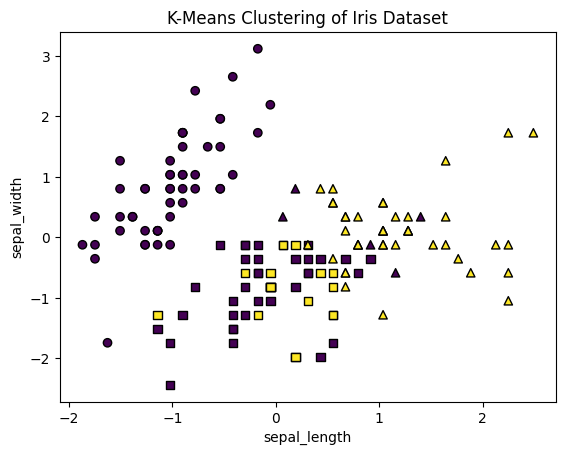

In [26]:
import matplotlib.pyplot as plt

# convert the actual species labels to numbers
y_numeric = y.map({
    'setosa': 0,
    'versicolor': 1,
    'virginica': 2
})

# get the cluster labels predicted by K-means
labels = km.labels_

# marker shapes for the three K-means clusters
markers = ['o', 's', '^']

# plot the first two standardized features
for cluster in range(3):
    plt.scatter(
        df.iloc[labels == cluster, 0],
        df.iloc[labels == cluster, 1],
        c=y_numeric[labels == cluster],
        cmap='viridis',
        marker=markers[cluster],
        edgecolor='k'
    )

plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.title('K-Means Clustering of Iris Dataset')
plt.show()

##Task 4: Conduct the DBSCAN cluster analysis

### Step 1: Determine the Parameters

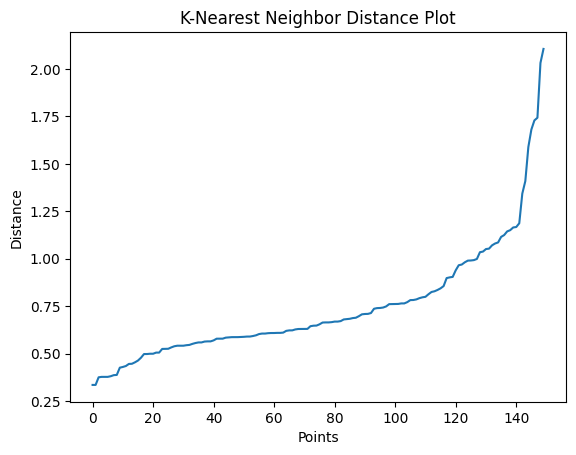

In [27]:
from sklearn.neighbors import NearestNeighbors
import numpy as np

# set the number of nearest neighbors
k = 11

# find the distances to each point's nearest neighbors
nn = NearestNeighbors(n_neighbors=k)
nn.fit(df)

distances, indices = nn.kneighbors(df)

# sort the distances to the 11th nearest neighbor
distances = np.sort(distances[:, k - 1])

# plot the sorted distances
plt.plot(distances)

plt.xlabel('Points')
plt.ylabel('Distance')
plt.title('K-Nearest Neighbor Distance Plot')
plt.show()

### Step 2: Fit the Model

In [28]:
from sklearn.cluster import DBSCAN

# create the DBSCAN model
db = DBSCAN(eps=1.3, min_samples=11)

# fit the model to the standardized data
db.fit(df)

# display the parameters of the fitted model
db.get_params()

{'algorithm': 'auto',
 'eps': 1.3,
 'leaf_size': 30,
 'metric': 'euclidean',
 'metric_params': None,
 'min_samples': 11,
 'n_jobs': None,
 'p': None}

DBSCAN was fitted to the standardized Iris data using eps=1.3 and min_samples=11. The eps parameter defines the neighborhood radius around each point, while min_samples specifies the minimum number of neighboring points required to form a dense region. The fit() method was then used to perform the DBSCAN cluster analysis.

##Task 5: Visualize the DBSCAN clusters

The DBSCAN clustering results were visualized using a scatterplot of the first two features, sepal_length and sepal_width. The color of each point represents its actual species label, while the marker shape represents the cluster assigned by DBSCAN. This visualization allows the actual Iris classes to be compared with the groups identified by the DBSCAN clustering algorithm.

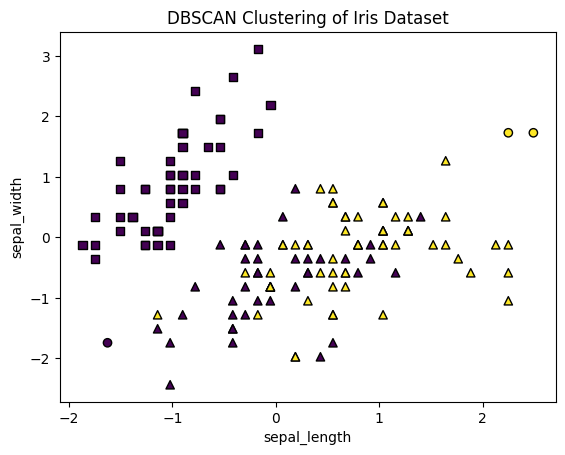

In [29]:
# get the cluster labels predicted by DBSCAN
labels = db.labels_

# get the unique DBSCAN cluster labels
unique_labels = np.unique(labels)

# create marker shapes for the DBSCAN labels
markers = ['o', 's', '^', 'x']

# plot the first two standardized features
for i, cluster in enumerate(unique_labels):
    mask = labels == cluster

    plt.scatter(
        df.iloc[mask, 0],
        df.iloc[mask, 1],
        c=y_numeric[mask],
        cmap='viridis',
        marker=markers[i],
        edgecolor='k'
    )

plt.xlabel('sepal_length')
plt.ylabel('sepal_width')
plt.title('DBSCAN Clustering of Iris Dataset')
plt.show()